Import Libraries and Load data

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [180]:
df = pd.read_csv("data/Churn_Modelling.csv")

Data Cleaning

In [181]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [182]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [184]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [185]:
df.duplicated().sum()

np.int64(0)

In [186]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [187]:
df=df.drop(columns=["RowNumber","CustomerId","Surname"])

In [188]:
cols = df.columns
cols

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [189]:
num_columns = df.select_dtypes(include="number").columns
print(num_columns)
#removing binary categorical columns
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
binary_cols = ['HasCrCard','IsActiveMember']

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [190]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['Geography', 'Gender'], dtype='object')

Exploratory Data Analysis

Univariate Analysis

In [191]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

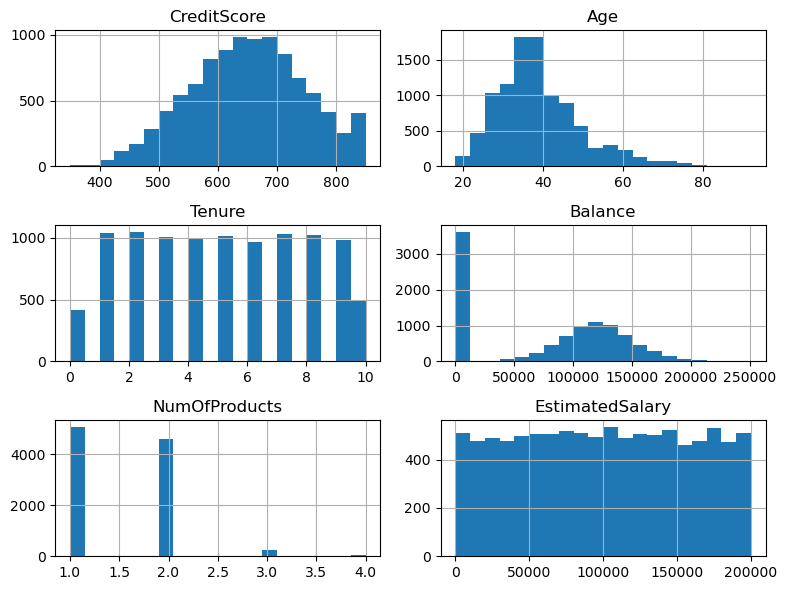

In [192]:
df[numerical_cols].hist(bins = 20,figsize = (8,6))
plt.tight_layout()

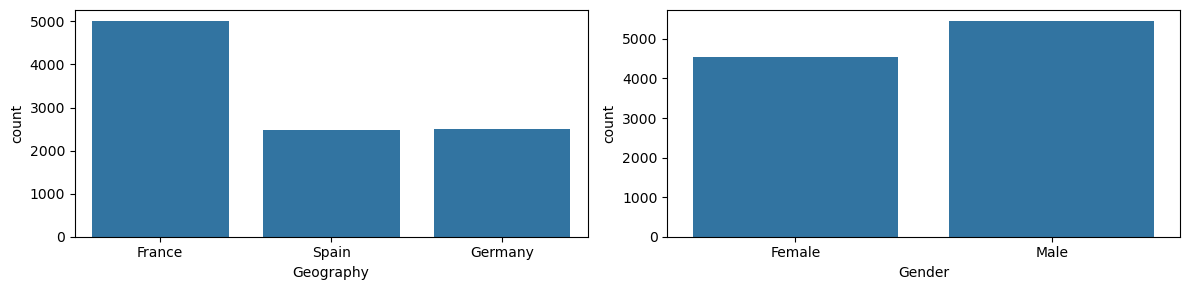

In [193]:
plt.figure(figsize=(12, 3))

for i,col in enumerate(categorical_cols):
 plt.subplot(1, 2, i+1)
 sns.countplot(data=df, x=col)
    
plt.tight_layout()
plt.show()

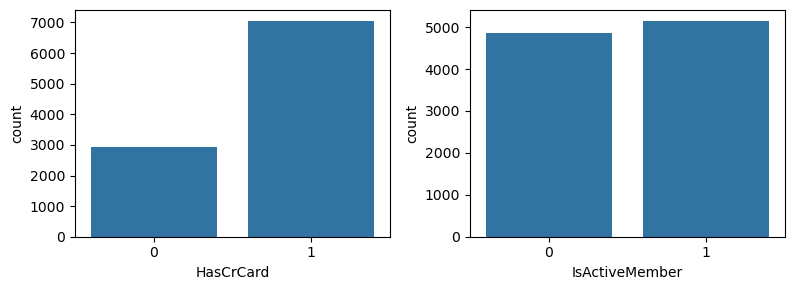

In [194]:
plt.figure(figsize=(12, 3))

for i,col in enumerate(binary_cols):
 plt.subplot(1, 3, i+1)
 sns.countplot(data=df, x=col)
    
plt.tight_layout()
plt.show()

In [195]:
df[num_columns].skew()

CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
Exited             1.471611
dtype: float64

Bivariate Analysis

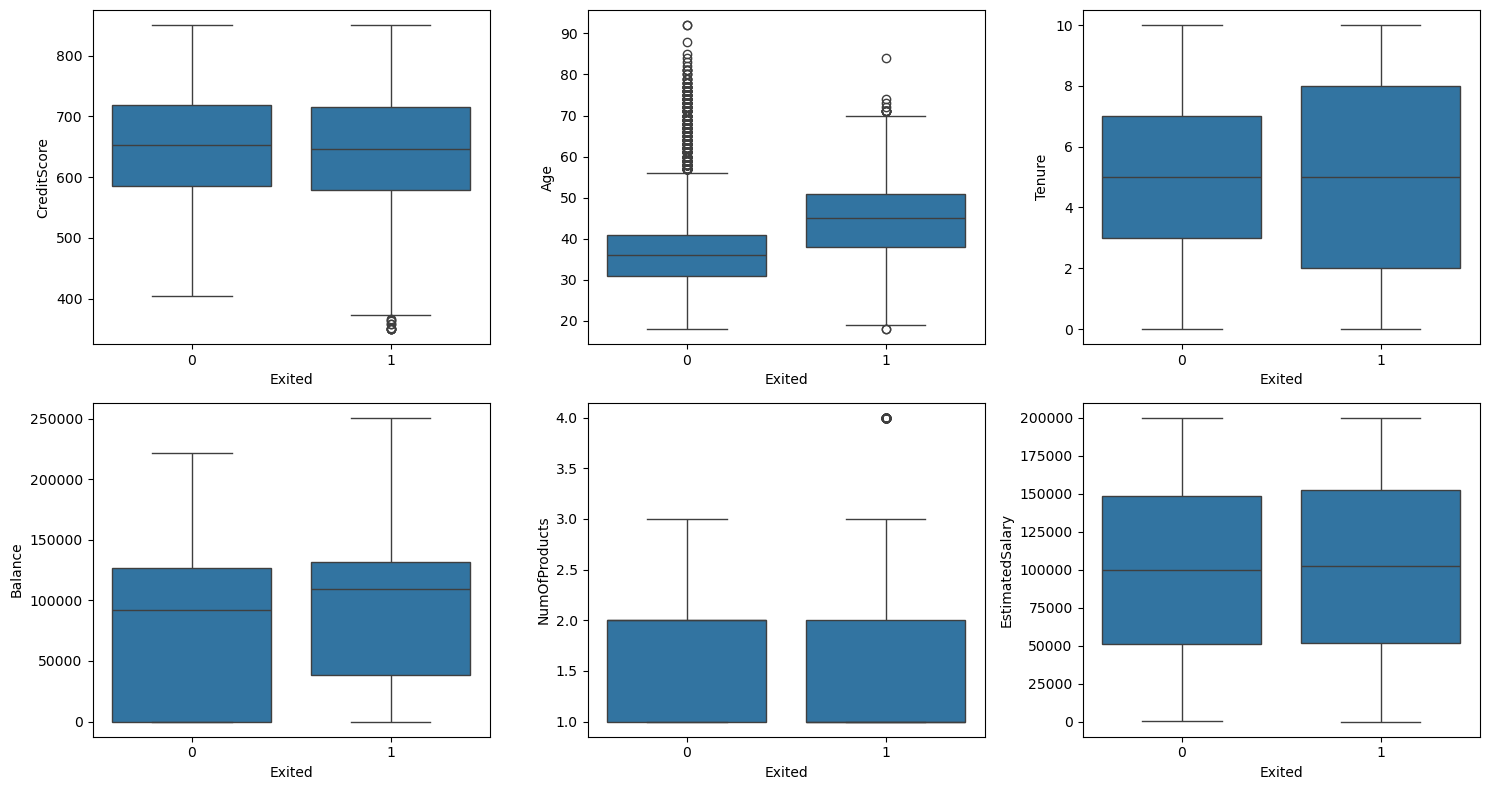

In [196]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df, x="Exited", y=col)

plt.tight_layout()
plt.show()

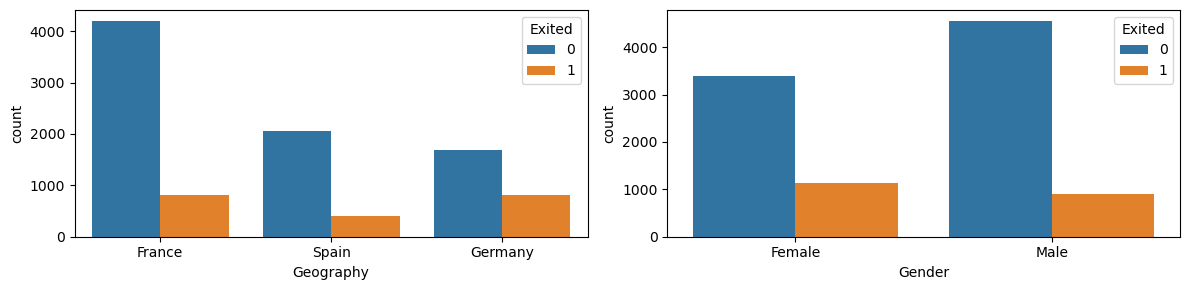

In [197]:
plt.figure(figsize=(12, 3))

for i,col in enumerate(categorical_cols):
 plt.subplot(1, 2, i+1)
 sns.countplot(data=df, x=col , hue="Exited")
    
plt.tight_layout()
plt.show()

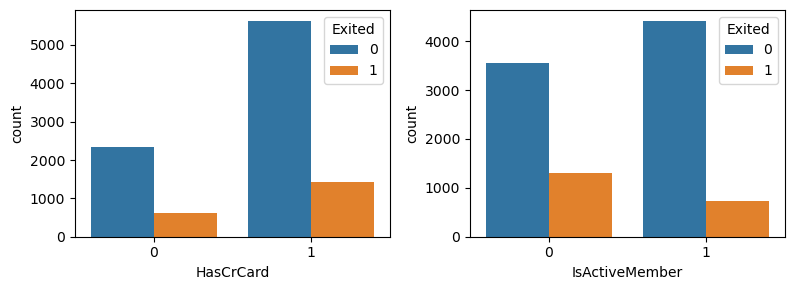

In [198]:
plt.figure(figsize=(12, 3))

for i,col in enumerate(binary_cols):
 plt.subplot(1, 3, i+1)
 sns.countplot(data=df, x=col , hue="Exited")
    
plt.tight_layout()
plt.show()

Multivariate

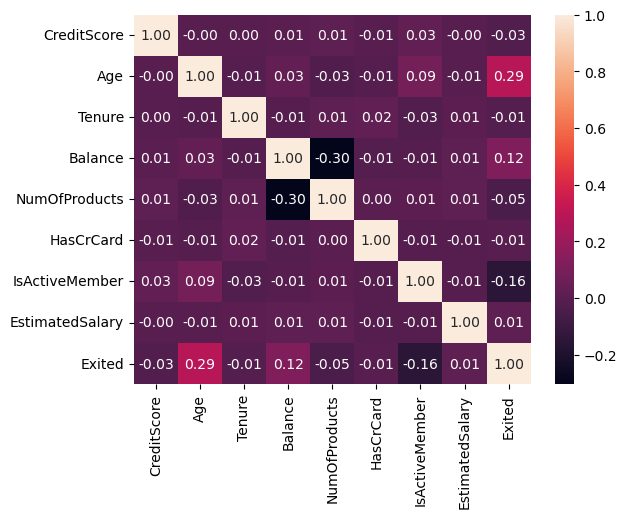

In [199]:
sns.heatmap(df.select_dtypes(include="number").corr(),annot=True,fmt=".2f")
plt.show()

In [200]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Train/Test Split

In [201]:
#feature and target selection
X = df.drop("Exited",axis=1)
y = df["Exited"]

In [202]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify = y) 
#stratify is used for same class proportion

Preprocessing: Pipeline and Column Transformation

In [203]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

In [204]:
print(numerical_cols,binary_cols,categorical_cols)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'] ['HasCrCard', 'IsActiveMember'] Index(['Geography', 'Gender'], dtype='object')


In [205]:
# pipeline for numerical columns
num_pipeline =  Pipeline(steps = [("scaler",StandardScaler())])

# pipeline for categorical columns
cat_pipeline =  Pipeline(steps = [("encode",OneHotEncoder())])

In [206]:
# Column Transformer
preprocessor = ColumnTransformer(transformers = [("numeric",num_pipeline,numerical_cols),
                                                 ("categorical",cat_pipeline,categorical_cols),
                                                 ("binary","passthrough",binary_cols)])

preprocessor

,transformers,"[('numeric', ...), ('categorical', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


Trying Multiple Algorithms

In [207]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,roc_auc_score
from sklearn.pipeline import Pipeline

In [208]:
models = {"LogisticRegression" :  LogisticRegression(class_weight="balanced",random_state=42),
          "DecisionTree" : DecisionTreeClassifier(class_weight="balanced",random_state=42),
          "RandomForest" : RandomForestClassifier(class_weight="balanced",random_state=42)
         }

In [209]:
results = []

for name,model in models.items():
   model_pipeline = Pipeline(steps=[("preproceesor",preprocessor),
                            ("classifier",model)])

   model_pipeline.fit(X_train,y_train)

   y_pred = model_pipeline.predict(X_test)

   results.append([name,accuracy_score(y_test,y_pred),
                  precision_score(y_test,y_pred),
                  recall_score(y_test,y_pred),
                  f1_score(y_test,y_pred),
                  confusion_matrix(y_test,y_pred),
                  roc_auc_score(y_test,y_pred)])
results_df = pd.DataFrame(results,columns=["model name","accuracy","precision","recall","f1 score","matrix","roc score"])

print(results_df)

           model name  accuracy  precision    recall  f1 score  \
0  LogisticRegression    0.7135   0.387228  0.700246  0.498688   
1        DecisionTree    0.7815   0.463592  0.469287  0.466422   
2        RandomForest    0.8570   0.771300  0.422604  0.546032   

                      matrix  roc score  
0  [[1142, 451], [122, 285]]   0.708566  
1  [[1372, 221], [216, 191]]   0.665278  
2   [[1542, 51], [235, 172]]   0.695295  


Hyperparameter Tuning

In [210]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps = [("preprocessor",preprocessor),
                                ("classifier",RandomForestClassifier(class_weight="balanced",random_state=42))])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

search = GridSearchCV(estimator=rf_pipeline,
                      param_grid=param_grid,
                      cv=5,
                      scoring="recall",
                      n_jobs=-1)

search.fit(X_train,y_train)                    

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...), ...]"


In [211]:
search.best_params_

{'classifier__max_depth': 5,
 'classifier__min_samples_leaf': 2,
 'classifier__min_samples_split': 10,
 'classifier__n_estimators': 200}

In [212]:
search.best_estimator_

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [213]:
search.best_score_

np.float64(0.7392638036809815)

In [214]:
rf_tuned = search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("Confusion matrix:",confusion_matrix(y_test, y_pred_tuned))
print("roc auc score:",roc_auc_score(y_test, y_pred_tuned))

Accuracy : 0.7945
Precision: 0.4967845659163987
Recall   : 0.7592137592137592
F1 Score : 0.6005830903790087
Confusion matrix: [[1280  313]
 [  98  309]]
roc auc score: 0.7813645695001626


Saving model

In [215]:
import joblib

joblib.dump(rf_tuned, "churn_model.pkl")
print("Model saved successfully")

Model saved successfully
